In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. CHARGEMENT DES DONNÉES
df = pd.read_csv('../data/clean_data.csv', encoding='ISO-8859-1')

In [15]:
#  KPI  : RÉTENTION & CHURN

# 1. PREMIÈRE ET DERNIÈRE COMMANDE PAR CLIENT
client_dates = df.groupby('CustomerID').agg(
    premiere_commande=('InvoiceDate', 'min'),
    derniere_commande=('InvoiceDate', 'max'),
    nb_commandes=('InvoiceNo', 'nunique'),
    ca_total=('CA', 'sum')
)

print(" PROFIL CLIENTS")
print(f"Total clients       : {len(client_dates)}")
print(f"Clients 1 commande  : {(client_dates['nb_commandes'] == 1).sum()}")
print(f"Clients récurrents  : {(client_dates['nb_commandes'] > 1).sum()}")


 PROFIL CLIENTS
Total clients       : 4338
Clients 1 commande  : 1493
Clients récurrents  : 2845



 RÉTENTION vs CHURN
 Taux de Rétention : 65.6%
 Taux de Churn     : 34.4%
   → 1493 clients n'ont JAMAIS racheté
   → 2845 clients sont REVENUS


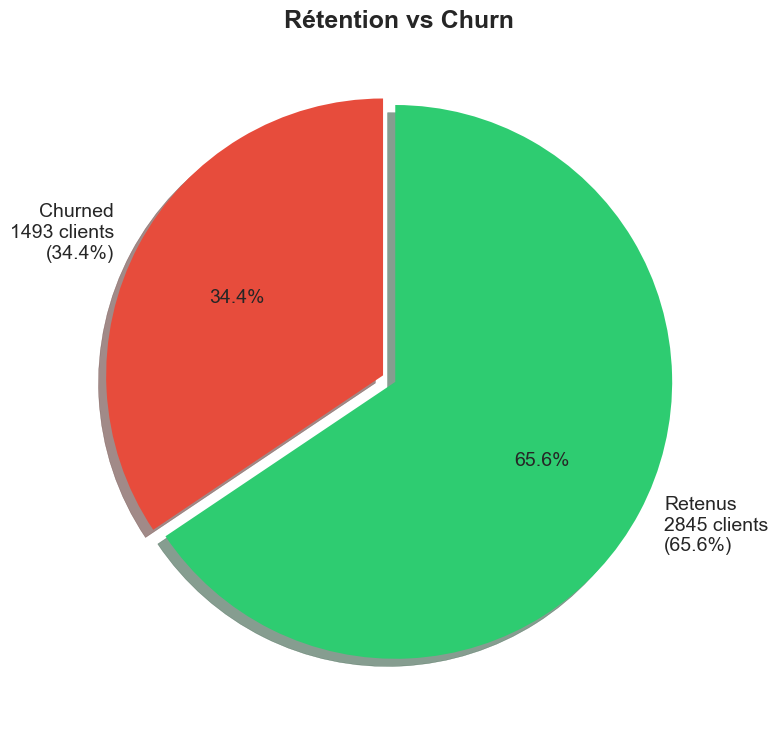

In [16]:
# 2. TAUX DE RÉTENTION SIMPLE

clients_une_fois = (client_dates['nb_commandes'] == 1).sum()
clients_recurrents = (client_dates['nb_commandes'] > 1).sum()
total_clients = len(client_dates)

taux_retention = (clients_recurrents / total_clients) * 100
taux_churn = (clients_une_fois / total_clients) * 100

print("\n RÉTENTION vs CHURN")
print(f" Taux de Rétention : {taux_retention:.1f}%")
print(f" Taux de Churn     : {taux_churn:.1f}%")
print(f"   → {clients_une_fois} clients n'ont JAMAIS racheté")
print(f"   → {clients_recurrents} clients sont REVENUS")

# Visualisation
plt.figure(figsize=(8, 8))
labels = [f'Churned\n{clients_une_fois} clients\n({taux_churn:.1f}%)', 
          f'Retenus\n{clients_recurrents} clients\n({taux_retention:.1f}%)']
sizes = [clients_une_fois, clients_recurrents]
colors = ['#e74c3c', '#2ecc71']
explode = (0.05, 0)

plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', textprops={'fontsize': 14},
        shadow=True, startangle=90)
plt.title(' Rétention vs Churn', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


In [19]:
#  FORCER LA CONVERSION
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df.dropna(subset=['InvoiceDate'], inplace=True)

print(f" Type : {df['InvoiceDate'].dtype}")


 Type : datetime64[ns]


In [20]:
# ========================================
# 📊 ANALYSE COHORTE
# ========================================

# Mois de première commande par client
df['MoisCohorte'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# Mois de la commande
df['MoisCommande'] = df['InvoiceDate'].dt.to_period('M')

# Différence en mois
df['IndexCohorte'] = (df['MoisCommande'].astype(int) - df['MoisCohorte'].astype(int))

# Tableau cohorte : nb clients uniques par cohorte et mois
cohorte_data = df.groupby(['MoisCohorte', 'IndexCohorte'])['CustomerID'].nunique().reset_index()
cohorte_data.columns = ['MoisCohorte', 'IndexCohorte', 'NbClients']

# Pivot
cohorte_pivot = cohorte_data.pivot(index='MoisCohorte', columns='IndexCohorte', values='NbClients')

# Taille initiale de chaque cohorte
taille_cohorte = cohorte_pivot[0]

cohorte_pct = cohorte_pivot.divide(taille_cohorte, axis=0) * 100

print(" cohorte_pct créé !")
print(cohorte_pct.head())


 cohorte_pct créé !
IndexCohorte     0          1          2          3          4          5   \
MoisCohorte                                                                  
2010-12       100.0  36.610169  32.316384  38.418079  36.271186  39.774011   
2011-01       100.0  22.062350  26.618705  23.021583  32.134293  28.776978   
2011-02       100.0  18.684211  18.684211  28.421053  27.105263  24.736842   
2011-03       100.0  15.044248  25.221239  19.911504  22.345133  16.814159   
2011-04       100.0  21.333333  20.333333  21.000000  19.666667  22.666667   

IndexCohorte         6          7          8          9          10  \
MoisCohorte                                                           
2010-12       36.271186  34.915254  35.367232  39.548023  37.401130   
2011-01       24.700240  24.220624  29.976019  32.613909  36.450839   
2011-02       25.263158  27.894737  24.736842  30.526316   6.842105   
2011-03       26.769912  23.008850  27.876106   8.628319        NaN   
2011-04

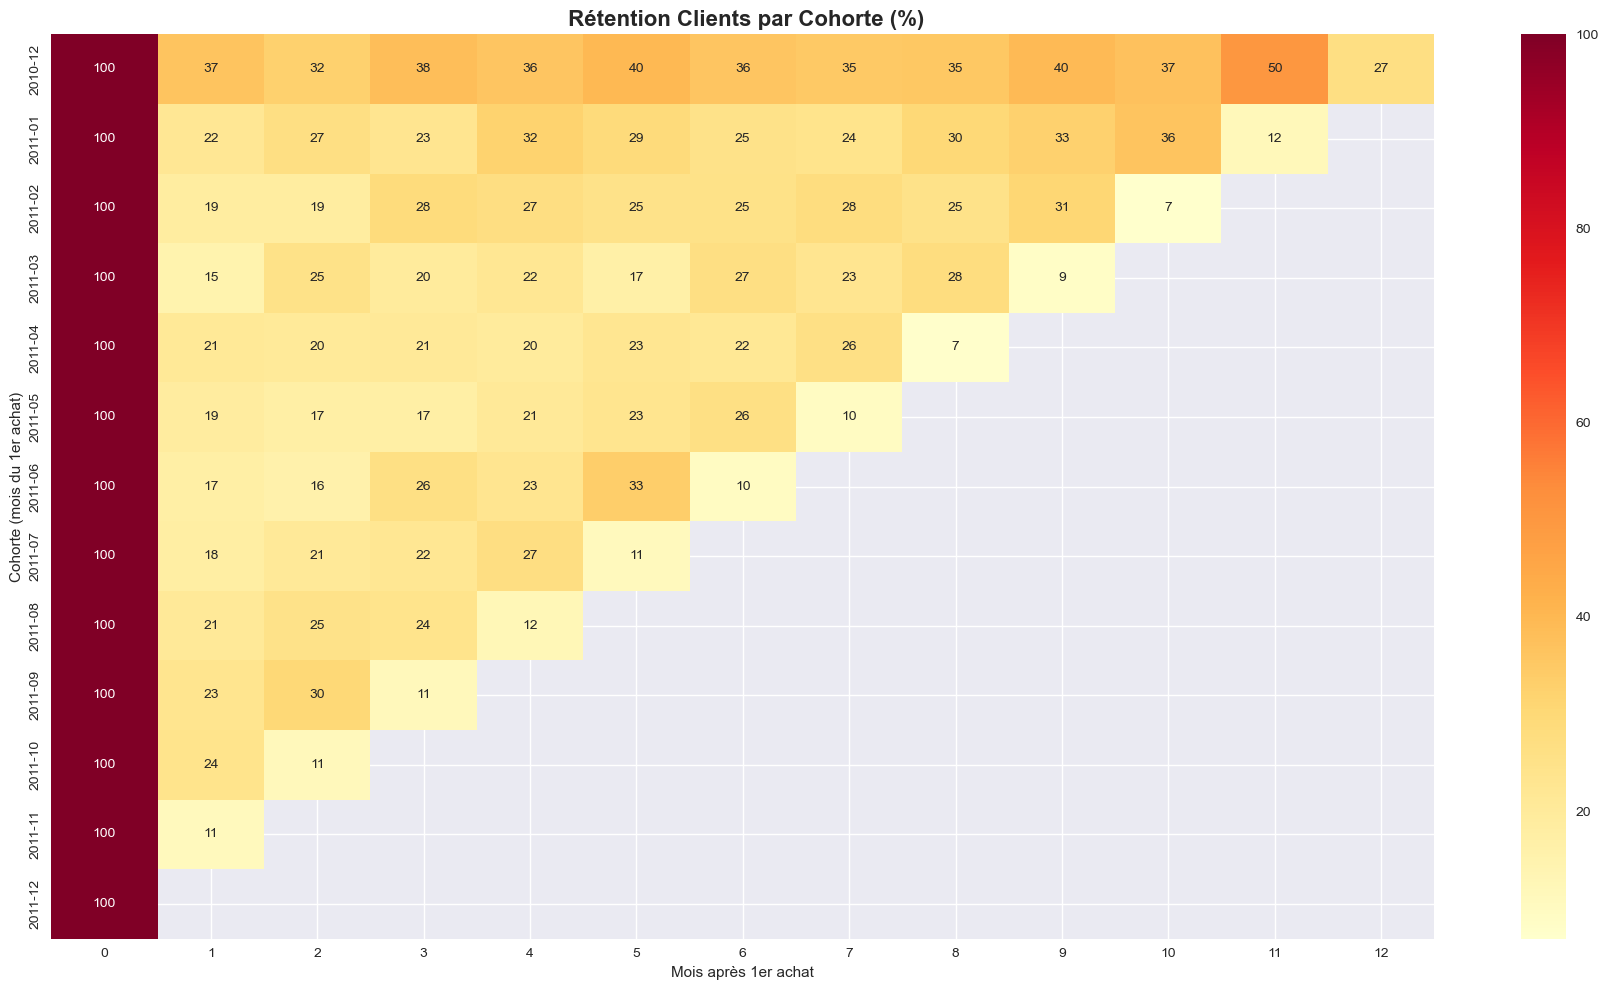

In [21]:
# ========================================
#  HEATMAP COHORTE
# ========================================
plt.figure(figsize=(18, 10))
sns.heatmap(cohorte_pct, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title(' Rétention Clients par Cohorte (%)', fontsize=16, fontweight='bold')
plt.xlabel('Mois après 1er achat')
plt.ylabel('Cohorte (mois du 1er achat)')
plt.tight_layout()
plt.show()


In [22]:
# 5. VALEUR CLIENT : QUI SONT LES MEILLEURS ?
client_dates['segment'] = pd.cut(client_dates['nb_commandes'], 
                                  bins=[0, 1, 3, 10, 100, 10000],
                                  labels=['1 achat', '2-3 achats', '4-10 achats', 
                                          '11-100 achats', '100+ achats'])

segment_stats = client_dates.groupby('segment').agg(
    nb_clients=('ca_total', 'count'),
    ca_moyen=('ca_total', 'mean'),
    ca_total=('ca_total', 'sum')
)
segment_stats['pct_clients'] = (segment_stats['nb_clients'] / total_clients * 100).round(1)
segment_stats['pct_ca'] = (segment_stats['ca_total'] / segment_stats['ca_total'].sum() * 100).round(1)

print("\n SEGMENTATION PAR FRÉQUENCE D'ACHAT")
print(segment_stats)



 SEGMENTATION PAR FRÉQUENCE D'ACHAT
               nb_clients      ca_moyen     ca_total  pct_clients  pct_ca
segment                                                                  
1 achat              1493    411.245520   613989.561         34.4     6.9
2-3 achats           1343   1032.453010  1386584.392         31.0    15.6
4-10 achats          1165   2148.213675  2502668.931         26.9    28.2
11-100 achats         334  12475.095240  4166681.810          7.7    46.9
100+ achats             3  72428.066667   217284.200          0.1     2.4


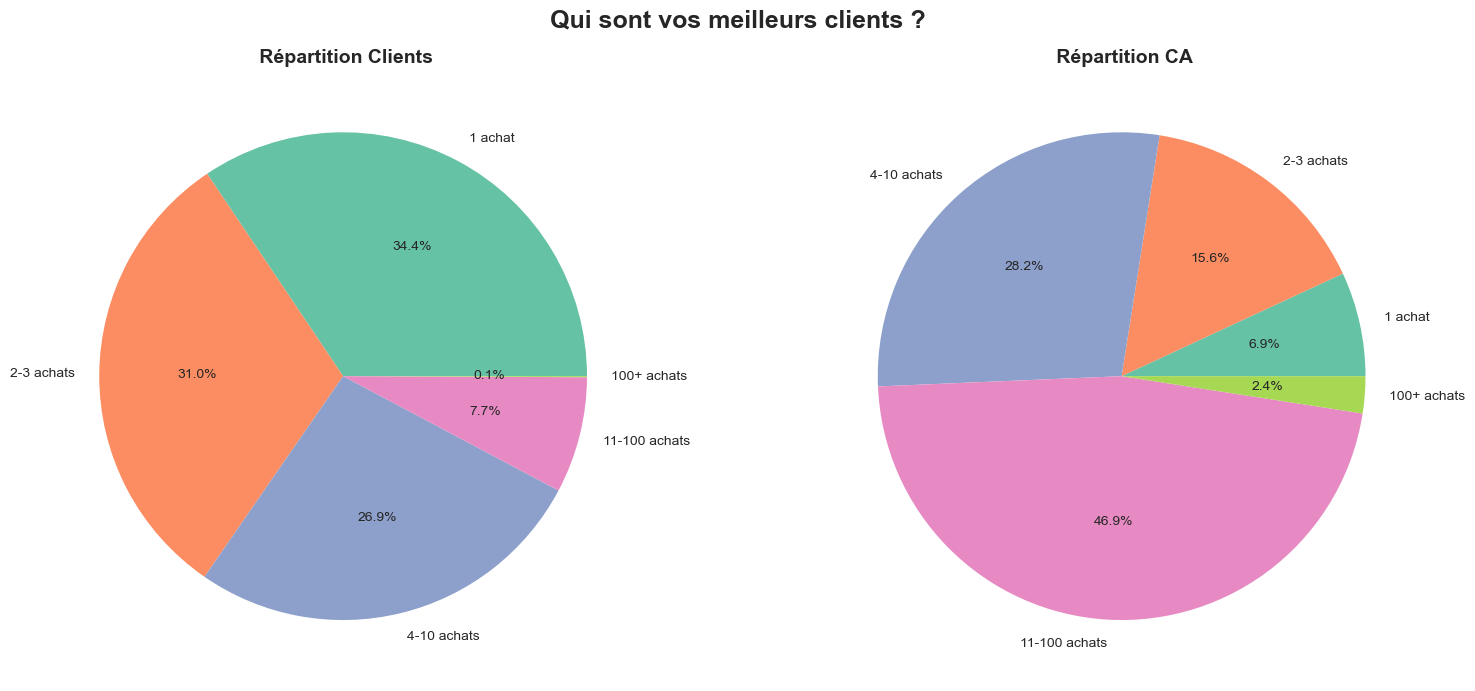

In [24]:
# 6. VISUALISATION SEGMENT
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# % Clients
axes[0].pie(segment_stats['nb_clients'], labels=segment_stats.index, 
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[0].set_title(' Répartition Clients', fontsize=14, fontweight='bold')

# % CA
axes[1].pie(segment_stats['ca_total'], labels=segment_stats.index, 
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title(' Répartition CA', fontsize=14, fontweight='bold')

plt.suptitle('Qui sont vos meilleurs clients ?', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


In [25]:
# 7. RÉCAPITULATIF KPI 2
print(" RÉCAPITULATIF KPI 2 - RÉTENTION & CHURN")
print(f" Taux de Rétention    : {taux_retention:.1f}%")
print(f" Taux de Churn        : {taux_churn:.1f}%")
print(f" Clients 1 achat      : {clients_une_fois}")
print(f" Clients récurrents   : {clients_recurrents}")
print(f" Commandes moy/client : {client_dates['nb_commandes'].mean():.1f}")
print(f" CA moyen/client      : £{client_dates['ca_total'].mean():,.2f}")


 RÉCAPITULATIF KPI 2 - RÉTENTION & CHURN
 Taux de Rétention    : 65.6%
 Taux de Churn        : 34.4%
 Clients 1 achat      : 1493
 Clients récurrents   : 2845
 Commandes moy/client : 4.3
 CA moyen/client      : £2,048.69
